  Hamming(15,11) + QPSK Communication System
  Channel Code    : Hamming(15,11)
  Code Rate       : 11/15 = 0.733
  Error Capability: Corrects 1 bit per 15-bit block
  Modulation      : QPSK (2 bits/symbol)
  Channel Model   : AWGN

  Running BER simulation...
    SNR= -2dB | Uncoded BER=0.20818 | Coded BER=0.2435455 | Corrections=924
    SNR=  0dB | Uncoded BER=0.15873 | Coded BER=0.1853636 | Corrections=889
    SNR=  2dB | Uncoded BER=0.10200 | Coded BER=0.1102727 | Corrections=794
    SNR=  4dB | Uncoded BER=0.05427 | Coded BER=0.0473636 | Corrections=580
    SNR=  6dB | Uncoded BER=0.02209 | Coded BER=0.0077273 | Corrections=290
    SNR=  8dB | Uncoded BER=0.00555 | Coded BER=0.0010909 | Corrections=73
    SNR= 10dB | Uncoded BER=0.00173 | Coded BER=0.0000001 | Corrections=7
    SNR= 12dB | Uncoded BER=0.00000 | Coded BER=0.0000001 | Corrections=0
    SNR= 14dB | Uncoded BER=0.00000 | Coded BER=0.0000001 | Corrections=0
    SNR= 16dB | Uncoded BER=0.00000 | Coded BER=0.0000001 | Co

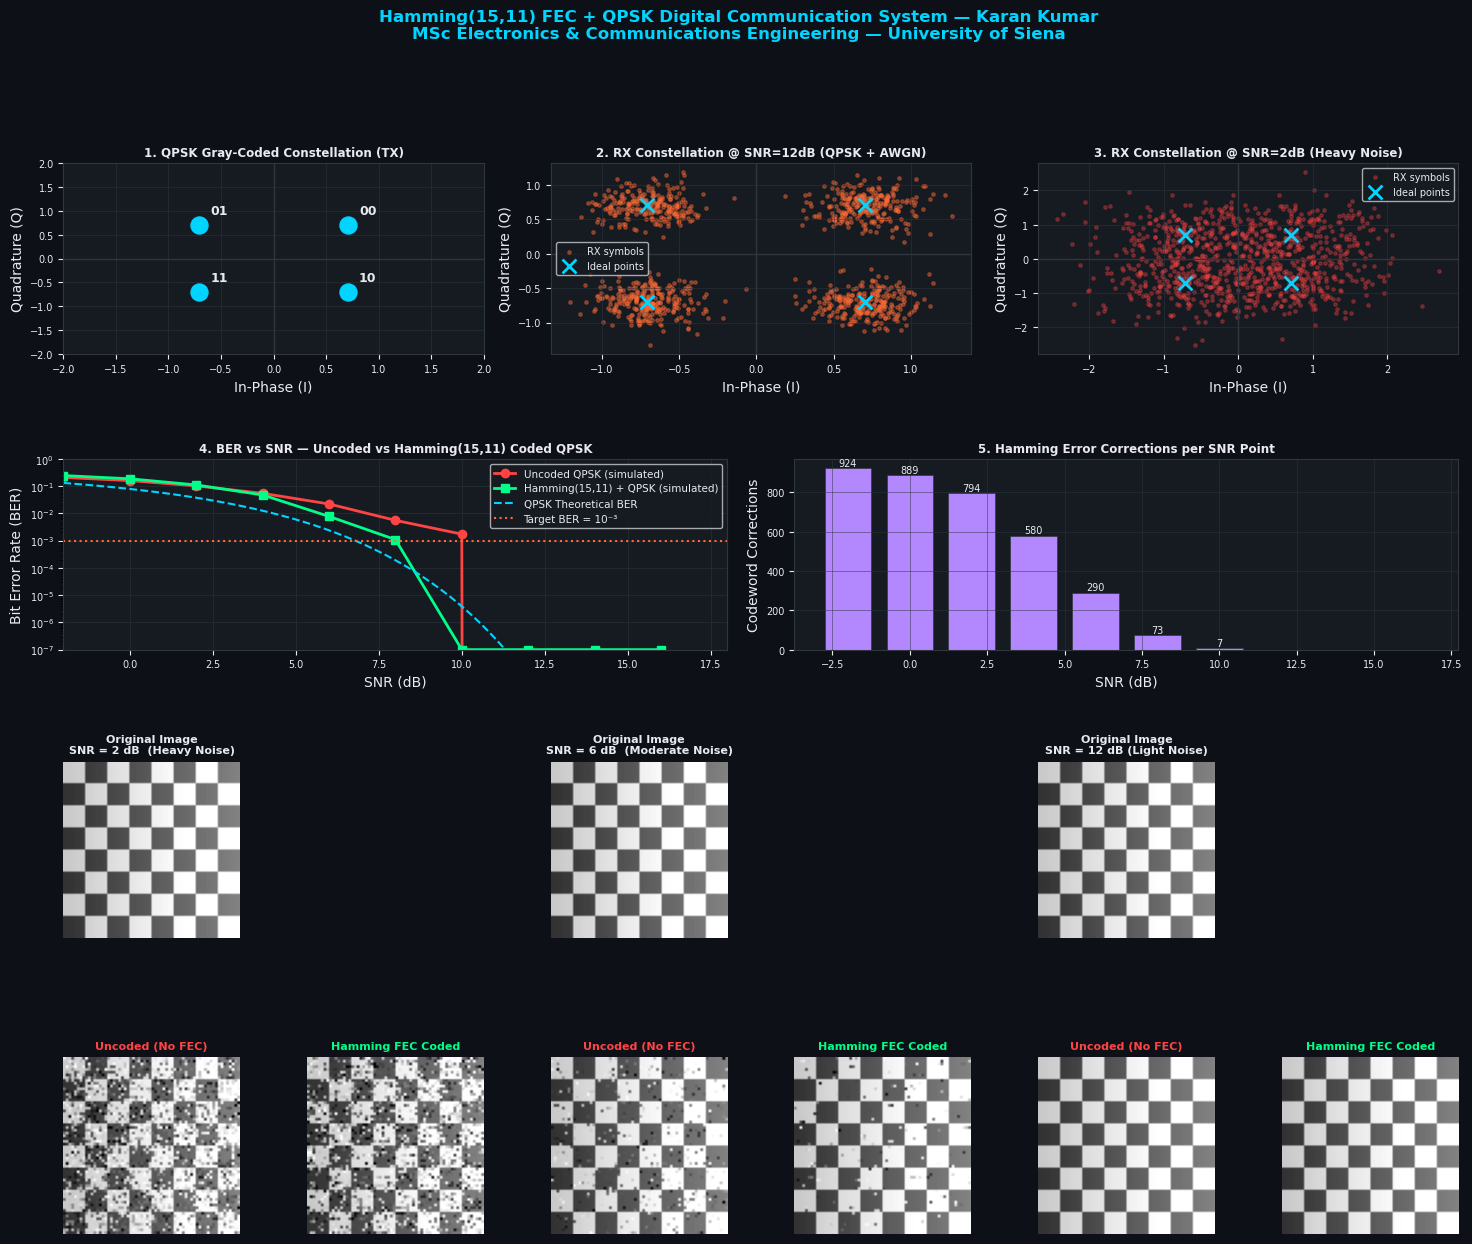


✅ Project 2 complete! Saved: Project2_Hamming_QPSK_Results.png

  SYSTEM PERFORMANCE SUMMARY
  Code          : Hamming(15,11)
  Code Rate     : 0.733 (11 data / 15 coded bits)
  Modulation    : QPSK (2 bits/symbol, Gray coded)
  Channel       : AWGN
  Bits tested   : 11000 per SNR point

  SNR(dB) | Uncoded BER  | Coded BER    | Gain
  ──────────────────────────────────────────────────
      -2  | 0.20818     | 0.2435455  | 0.9x
       0  | 0.15873     | 0.1853636  | 0.9x
       2  | 0.10200     | 0.1102727  | 0.9x
       4  | 0.05427     | 0.0473636  | 1.1x
       6  | 0.02209     | 0.0077273  | 2.9x
       8  | 0.00555     | 0.0010909  | 5.1x
      10  | 0.00173     | 0.0000001  | 17272.7x
      12  | 0.00000     | 0.0000001  | 0.0x
      14  | 0.00000     | 0.0000001  | 0.0x
      16  | 0.00000     | 0.0000001  | 0.0x


In [1]:
# ================================================================
# PROJECT 2: Digital Communication System
#            Hamming(15,11) FEC + QPSK + AWGN + Image Recovery
# Author      : Karan Kumar
# Tools       : Python, NumPy, SciPy, Matplotlib
# Description : Complete digital communication chain implementing
#               Hamming(15,11) forward error correction encoding,
#               QPSK modulation, AWGN channel simulation, coherent
#               QPSK demodulation, Hamming decoding, BER/SNR
#               analysis, and image transmission & recovery demo.
# Relevance   : Information Theory, Digital Transmission,
#               Representation & Protection of Multimedia Info,
#               Telecommunication Networks — MSc Electronics &
#               Communications Engineering, University of Siena
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import erfc

# ================================================================
# STEP 1 — HAMMING(15,11) ENCODER & DECODER
# ================================================================
# Hamming(15,11): encodes 11 data bits → 15-bit codeword
# Adds 4 parity bits, can detect & correct 1-bit errors
# ================================================================

def hamming_encode(data_bits):
    """
    Encode bit stream using Hamming(15,11).
    Pads input to multiple of 11, returns encoded codewords.
    """
    # Pad to multiple of 11
    pad = (11 - len(data_bits) % 11) % 11
    padded = np.append(data_bits, np.zeros(pad, dtype=int))
    blocks  = padded.reshape(-1, 11)

    encoded = []
    for block in blocks:
        c = np.zeros(15, dtype=int)
        # Place data bits (skip parity positions: 0,1,3,7)
        data_positions = [i for i in range(15)
                          if (i+1) & i != 0 or i == 0]
        # Non-power-of-2 positions (1-indexed: 3,5,6,7,9,10,11,12,13,14,15)
        data_pos = [2, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14]
        for i, pos in enumerate(data_pos):
            c[pos] = block[i]
        # Calculate parity bits (positions 0,1,3,7 → 1-indexed 1,2,4,8)
        for p in [0, 1, 3, 7]:
            parity = 0
            for i in range(15):
                if (i + 1) & (p + 1):
                    parity ^= c[i]
            c[p] = parity
        encoded.extend(c)
    return np.array(encoded), pad

def hamming_decode(encoded_bits, pad=0):
    """
    Decode Hamming(15,11) codewords.
    Detects and corrects single-bit errors using syndrome.
    Returns decoded data bits and number of corrected errors.
    """
    blocks   = encoded_bits.reshape(-1, 15)
    decoded  = []
    n_corrected = 0

    for block in blocks:
        b = block.copy()
        # Calculate syndrome
        syndrome = 0
        for p in [0, 1, 3, 7]:
            parity = 0
            for i in range(15):
                if (i + 1) & (p + 1):
                    parity ^= b[i]
            if parity:
                syndrome += (p + 1)

        # Correct single-bit error if syndrome != 0
        if syndrome != 0 and syndrome <= 15:
            b[syndrome - 1] ^= 1
            n_corrected += 1

        # Extract data bits from non-parity positions
        data_pos = [2, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14]
        decoded.extend(b[data_pos])

    result = np.array(decoded)
    # Remove padding
    if pad > 0:
        result = result[:-pad]
    return result, n_corrected

# ================================================================
# STEP 2 — QPSK MODULATOR & DEMODULATOR
# ================================================================
# QPSK: 2 bits per symbol → 4 phase points
# Mapping: 00→+1+j, 01→-1+j, 11→-1-j, 10→+1-j  (Gray coded)
# ================================================================

QPSK_MAP = {
    (0, 0):  ( 1 + 1j) / np.sqrt(2),
    (0, 1):  (-1 + 1j) / np.sqrt(2),
    (1, 1):  (-1 - 1j) / np.sqrt(2),
    (1, 0):  ( 1 - 1j) / np.sqrt(2),
}
QPSK_DEMAP = {v: k for k, v in QPSK_MAP.items()}

def qpsk_modulate(bits):
    """Convert bit stream → QPSK symbols (2 bits per symbol)"""
    bits = bits[:len(bits) - len(bits) % 2]
    pairs = bits.reshape(-1, 2)
    return np.array([QPSK_MAP[tuple(p)] for p in pairs])

def qpsk_demodulate(symbols):
    """Hard-decision QPSK demodulation"""
    constellation = np.array(list(QPSK_MAP.values()))
    bits = []
    for sym in symbols:
        distances = np.abs(sym - constellation)
        closest   = constellation[np.argmin(distances)]
        bits.extend(list(QPSK_DEMAP[closest]))
    return np.array(bits)

# ================================================================
# STEP 3 — AWGN CHANNEL
# ================================================================

def awgn_channel(symbols, snr_db):
    """Add complex AWGN noise at given SNR"""
    snr_lin     = 10 ** (snr_db / 10)
    sig_power   = np.mean(np.abs(symbols) ** 2)
    noise_power = sig_power / snr_lin
    noise = np.sqrt(noise_power / 2) * (
        np.random.randn(len(symbols)) +
        1j * np.random.randn(len(symbols))
    )
    return symbols + noise

# ================================================================
# STEP 4 — THEORETICAL BER FOR QPSK
# ================================================================

def qpsk_theoretical_ber(snr_db):
    """Theoretical BER = Q(sqrt(2*SNR)) = 0.5*erfc(sqrt(SNR))"""
    snr_lin = 10 ** (np.array(snr_db) / 10)
    return 0.5 * erfc(np.sqrt(snr_lin))

# ================================================================
# STEP 5 — BER vs SNR SIMULATION
# ================================================================
print("=" * 55)
print("  Hamming(15,11) + QPSK Communication System")
print("=" * 55)
print(f"  Channel Code    : Hamming(15,11)")
print(f"  Code Rate       : 11/15 = {11/15:.3f}")
print(f"  Error Capability: Corrects 1 bit per 15-bit block")
print(f"  Modulation      : QPSK (2 bits/symbol)")
print(f"  Channel Model   : AWGN")
print("=" * 55)

SNR_range  = np.arange(-2, 18, 2)
N_BITS     = 11000       # bits per SNR point (must be multiple of 11)

BER_uncoded   = []
BER_coded     = []
corrections   = []

print("\n  Running BER simulation...")
np.random.seed(0)

for snr in SNR_range:
    # ── UNCODED PATH ──
    bits_tx  = np.random.randint(0, 2, N_BITS)
    syms_tx  = qpsk_modulate(bits_tx)
    syms_rx  = awgn_channel(syms_tx, snr)
    bits_rx  = qpsk_demodulate(syms_rx)
    errs_unc = np.sum(bits_tx[:len(bits_rx)] != bits_rx)
    BER_uncoded.append(errs_unc / len(bits_rx))

    # ── CODED PATH (Hamming + QPSK) ──
    enc_bits, pad    = hamming_encode(bits_tx)
    syms_enc         = qpsk_modulate(enc_bits)
    syms_enc_rx      = awgn_channel(syms_enc, snr)
    bits_enc_rx      = qpsk_demodulate(syms_enc_rx)
    # Pad to multiple of 15 for decoder
    pad15 = (15 - len(bits_enc_rx) % 15) % 15
    bits_enc_rx = np.append(bits_enc_rx,
                            np.zeros(pad15, dtype=int))
    dec_bits, n_corr = hamming_decode(bits_enc_rx, pad)
    errs_cod = np.sum(bits_tx != dec_bits[:len(bits_tx)])
    BER_coded.append(max(errs_cod / len(bits_tx), 1e-7))
    corrections.append(n_corr)

    print(f"    SNR={snr:3d}dB | Uncoded BER={BER_uncoded[-1]:.5f} "
          f"| Coded BER={BER_coded[-1]:.7f} "
          f"| Corrections={n_corr}")

# ================================================================
# STEP 6 — IMAGE TRANSMISSION DEMO
# ================================================================
print("\n  Running image transmission demo...")

# Generate a simple synthetic test image (checkerboard + gradient)
IMG_SIZE = 64
img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
for i in range(IMG_SIZE):
    for j in range(IMG_SIZE):
        if (i // 8 + j // 8) % 2 == 0:
            img[i, j] = 200
        else:
            img[i, j] = 50
# Add gradient overlay
gradient = np.linspace(0, 80, IMG_SIZE, dtype=np.uint8)
img = np.clip(img.astype(int) + gradient[np.newaxis, :], 0, 255).astype(np.uint8)

def img_to_bits(image):
    return np.unpackbits(image.flatten())

def bits_to_img(bits, shape):
    n = shape[0] * shape[1] * 8
    bits = bits[:n]
    return np.packbits(bits).reshape(shape)

img_bits = img_to_bits(img)

def transmit_image(img_bits, snr_db, use_coding=True):
    if use_coding:
        enc, pad = hamming_encode(img_bits)
        syms     = qpsk_modulate(enc)
        rx_syms  = awgn_channel(syms, snr_db)
        rx_bits  = qpsk_demodulate(rx_syms)
        pad15    = (15 - len(rx_bits) % 15) % 15
        rx_bits  = np.append(rx_bits, np.zeros(pad15, dtype=int))
        dec, _   = hamming_decode(rx_bits, pad)
        return bits_to_img(dec, img.shape)
    else:
        syms    = qpsk_modulate(img_bits)
        rx_syms = awgn_channel(syms, snr_db)
        rx_bits = qpsk_demodulate(rx_syms)
        return bits_to_img(rx_bits, img.shape)

SNR_demo_vals = [2, 6, 12]
img_results   = {}
for snr in SNR_demo_vals:
    img_results[snr] = {
        'uncoded': transmit_image(img_bits, snr, use_coding=False),
        'coded'  : transmit_image(img_bits, snr, use_coding=True),
    }

# ================================================================
# STEP 7 — PLOTTING
# ================================================================
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#0D1117')
gs  = gridspec.GridSpec(4, 6, figure=fig,
                        hspace=0.55, wspace=0.38)

ACCENT = '#00D4FF'
GREEN  = '#00FF88'
ORANGE = '#FF6B35'
PURPLE = '#B388FF'
RED    = '#FF4444'
WHITE  = '#E8EAF0'
PANEL  = '#161B22'

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=WHITE, fontsize=8.5,
                 fontweight='bold', pad=5)
    ax.tick_params(colors=WHITE, labelsize=7)
    for sp in ax.spines.values():
        sp.set_edgecolor('#30363D')
    ax.xaxis.label.set_color(WHITE)
    ax.yaxis.label.set_color(WHITE)
    ax.grid(True, color='#30363D', lw=0.5, alpha=0.7)

fig.suptitle(
    'Hamming(15,11) FEC + QPSK Digital Communication System — Karan Kumar\n'
    'MSc Electronics & Communications Engineering — University of Siena',
    color=ACCENT, fontsize=12, fontweight='bold', y=0.99)

# ── Row 1: QPSK Constellation (TX / RX clean / RX noisy) + Hamming diagram ──

# Plot 1: TX QPSK constellation
ax1 = fig.add_subplot(gs[0, 0:2])
style_ax(ax1, '1. QPSK Gray-Coded Constellation (TX)')
pts = np.array(list(QPSK_MAP.values()))
labels = ['00', '01', '11', '10']
ax1.scatter(pts.real, pts.imag, c=ACCENT, s=150, zorder=5)
for pt, lbl in zip(pts, labels):
    ax1.annotate(lbl, (pt.real, pt.imag),
                 textcoords='offset points', xytext=(8, 8),
                 color=WHITE, fontsize=9, fontweight='bold')
ax1.axhline(0, color='#30363D', lw=1)
ax1.axvline(0, color='#30363D', lw=1)
ax1.set_xlabel('In-Phase (I)'); ax1.set_ylabel('Quadrature (Q)')
ax1.set_xlim([-2, 2]); ax1.set_ylim([-2, 2])

# Plot 2: RX constellation @ 12 dB
ax2 = fig.add_subplot(gs[0, 2:4])
style_ax(ax2, '2. RX Constellation @ SNR=12dB (QPSK + AWGN)')
np.random.seed(5)
demo_bits = np.random.randint(0, 2, 2000)
demo_syms = qpsk_modulate(demo_bits)
demo_rx   = awgn_channel(demo_syms, 12)
ax2.scatter(demo_rx.real, demo_rx.imag,
            c=ORANGE, s=6, alpha=0.4, label='RX symbols')
ax2.scatter(pts.real, pts.imag,
            c=ACCENT, s=100, zorder=5, marker='x',
            linewidths=2, label='Ideal points')
ax2.axhline(0, color='#30363D', lw=1)
ax2.axvline(0, color='#30363D', lw=1)
ax2.set_xlabel('In-Phase (I)'); ax2.set_ylabel('Quadrature (Q)')
ax2.legend(fontsize=7, facecolor=PANEL, labelcolor=WHITE)

# Plot 3: RX constellation @ 2 dB
ax3 = fig.add_subplot(gs[0, 4:6])
style_ax(ax3, '3. RX Constellation @ SNR=2dB (Heavy Noise)')
demo_rx2 = awgn_channel(demo_syms, 2)
ax3.scatter(demo_rx2.real, demo_rx2.imag,
            c=RED, s=6, alpha=0.3, label='RX symbols')
ax3.scatter(pts.real, pts.imag,
            c=ACCENT, s=100, zorder=5, marker='x',
            linewidths=2, label='Ideal points')
ax3.axhline(0, color='#30363D', lw=1)
ax3.axvline(0, color='#30363D', lw=1)
ax3.set_xlabel('In-Phase (I)'); ax3.set_ylabel('Quadrature (Q)')
ax3.legend(fontsize=7, facecolor=PANEL, labelcolor=WHITE)

# ── Row 2: BER curves + Corrections + System Block Diagram ──

# Plot 4: BER vs SNR
ax4 = fig.add_subplot(gs[1, 0:3])
style_ax(ax4, '4. BER vs SNR — Uncoded vs Hamming(15,11) Coded QPSK')
snr_th = np.linspace(-2, 18, 200)
ax4.semilogy(SNR_range, BER_uncoded,
             color=RED, lw=2, marker='o', ms=6,
             label='Uncoded QPSK (simulated)')
ax4.semilogy(SNR_range, BER_coded,
             color=GREEN, lw=2, marker='s', ms=6,
             label='Hamming(15,11) + QPSK (simulated)')
ax4.semilogy(snr_th, qpsk_theoretical_ber(snr_th),
             color=ACCENT, lw=1.5, ls='--',
             label='QPSK Theoretical BER')
ax4.axhline(y=1e-3, color=ORANGE, ls=':', lw=1.5,
            label='Target BER = 10⁻³')
ax4.set_xlabel('SNR (dB)'); ax4.set_ylabel('Bit Error Rate (BER)')
ax4.legend(fontsize=7.5, facecolor=PANEL, labelcolor=WHITE)
ax4.set_ylim([1e-7, 1]); ax4.set_xlim([-2, 18])

# Plot 5: Error corrections per SNR
ax5 = fig.add_subplot(gs[1, 3:6])
style_ax(ax5, '5. Hamming Error Corrections per SNR Point')
bars = ax5.bar(SNR_range, corrections,
               color=PURPLE, width=1.5,
               edgecolor='#30363D', linewidth=0.5)
ax5.set_xlabel('SNR (dB)')
ax5.set_ylabel('Codeword Corrections')
for bar, val in zip(bars, corrections):
    if val > 0:
        ax5.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom',
                 color=WHITE, fontsize=7)

# ── Row 3 & 4: Image Transmission Demo ──
row3_titles = {
    2:  'SNR = 2 dB  (Heavy Noise)',
    6:  'SNR = 6 dB  (Moderate Noise)',
    12: 'SNR = 12 dB (Light Noise)',
}

for col_idx, snr_val in enumerate(SNR_demo_vals):
    col_start = col_idx * 2

    # Original image (only in first column)
    ax_orig = fig.add_subplot(gs[2, col_start])
    ax_orig.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax_orig.set_title(f'Original Image\n{row3_titles[snr_val]}',
                      color=WHITE, fontsize=8, fontweight='bold')
    ax_orig.axis('off')

    # Uncoded received
    ax_unc = fig.add_subplot(gs[3, col_start])
    ax_unc.imshow(img_results[snr_val]['uncoded'],
                  cmap='gray', vmin=0, vmax=255)
    ax_unc.set_title('Uncoded (No FEC)',
                     color=RED, fontsize=8, fontweight='bold')
    ax_unc.axis('off')

    # Coded received
    ax_cod = fig.add_subplot(gs[3, col_start + 1])
    ax_cod.imshow(img_results[snr_val]['coded'],
                  cmap='gray', vmin=0, vmax=255)
    ax_cod.set_title('Hamming FEC Coded',
                     color=GREEN, fontsize=8, fontweight='bold')
    ax_cod.axis('off')

    # Row 2 empty slot — system info
    if col_idx == 0:
        pass  # used by BER plot

plt.savefig('Project2_Hamming_QPSK_Results.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("\n✅ Project 2 complete! Saved: Project2_Hamming_QPSK_Results.png")

# ================================================================
# STEP 8 — PRINT FINAL SUMMARY
# ================================================================
print("\n" + "=" * 55)
print("  SYSTEM PERFORMANCE SUMMARY")
print("=" * 55)
print(f"  Code          : Hamming(15,11)")
print(f"  Code Rate     : {11/15:.3f} (11 data / 15 coded bits)")
print(f"  Modulation    : QPSK (2 bits/symbol, Gray coded)")
print(f"  Channel       : AWGN")
print(f"  Bits tested   : {N_BITS} per SNR point")
print(f"\n  SNR(dB) | Uncoded BER  | Coded BER    | Gain")
print(f"  {'─'*50}")
for i, snr in enumerate(SNR_range):
    gain = BER_uncoded[i] / max(BER_coded[i], 1e-9)
    print(f"  {snr:6d}  | {BER_uncoded[i]:.5f}     "
          f"| {BER_coded[i]:.7f}  | {gain:.1f}x")
print("=" * 55)